### Setup and data loading

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

df = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

blank = df["TotalCharges"].str.strip().eq("")
df.loc[blank, "TotalCharges"] = 0

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

### Data exploration

In [2]:
total_counts = df["Contract"].value_counts()
contract_filter = df["Churn"].eq("Yes")
contract = df[contract_filter]
total_churns = contract["Contract"].value_counts()

total_precentage = total_churns / total_counts
print("Churn percentage by contract:")
print(total_precentage * 100)

tenure_by_contract = df.groupby("Contract")["tenure"]
median_tenure_by_contract = tenure_by_contract.median()
print("\nMedian tenure by contract:")
print(median_tenure_by_contract)


tenure_by_churn = df.groupby("Churn")["tenure"]
median_tenure_by_churn = tenure_by_churn.median()
print("\nMedian tenure by churn:")
print(median_tenure_by_churn)

Churn percentage by contract:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: count, dtype: float64

Median tenure by contract:
Contract
Month-to-month    12.0
One year          44.0
Two year          64.0
Name: tenure, dtype: float64

Median tenure by churn:
Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64


### Train, validation and test split

In [3]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=104,
    test_size=0.20,
    stratify=y
)

X_train_small, X_validation, y_train_small, y_validation = train_test_split(
    X_train,
    y_train,
    random_state=104,
    test_size=0.25,
    stratify=y_train
)

### Baseline model

In [4]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train_small, y_train_small)

predictions_dummy_clf = dummy_clf.predict(X_validation)

conf_matrix = confusion_matrix(y_validation, predictions_dummy_clf)

print("Baseline confusion matrix:")
print(conf_matrix)

Baseline confusion matrix:
[[1035    0]
 [ 374    0]]


### Preprocessing

In [5]:
X_train_small.dtypes

objects = X_train_small.drop(
    columns=["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
).columns

quantity = ["tenure", "MonthlyCharges", "TotalCharges"]

preprocessor = ColumnTransformer(
    [
        ("objects_encoding", OneHotEncoder(handle_unknown="ignore"), objects),
        ("quantity_encoding", StandardScaler(), quantity)
    ],
    remainder="passthrough"
)

### Logistic regression

In [6]:
pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("logistic_regression", LogisticRegression())
])

pipe.fit(X_train_small, y_train_small)

predictions_pipe = pipe.predict(X_validation)

print("Logistic Regression - Threshold 0.50:")
print(confusion_matrix(y_validation, predictions_pipe))

Logistic Regression - Threshold 0.50:
[[918 117]
 [174 200]]


### Adjusting the classification threshold

In [7]:
probabilities = pipe.predict_proba(X_validation)
churn_probabilities = probabilities[:, 1]

predictions_035 = np.where(
    churn_probabilities >= 0.35,
    "Yes",
    "No"
)

print("Logistic Regression - Threshold 0.35:")
print(confusion_matrix(y_validation, predictions_035))

Logistic Regression - Threshold 0.35:
[[835 200]
 [113 261]]


### Logistic regression: validation results

| Churn threshold | Customers flagged | Churners found | Stayers flagged | Precision | Recall |
|---|---:|---:|---:|---:|---:|
| 0.50 | 317 | 200 | 117 | 63.1% | 53.5% |
| 0.35 | 461 | 261 | 200 | 56.6% | 69.8% |

I would consider the 0.35 threshold if missing a churner costs more than contacting a customer who stays. It found 61 more churners but required 144 more contacts. The dataset does not show whether contacting them would prevent churn.

In [8]:
#XGB 

y_train_xgb = y_train_small.map({"No": 0, "Yes": 1})
y_validation_xgb = y_validation.map({"No": 0, "Yes": 1})


pipe_xgb = Pipeline([
    ('preprocessing', preprocessor), 
    ('XGB', XGBClassifier())
])

pipe_xgb.fit(X_train_small, y_train_xgb)
predictions_xgb = pipe_xgb.predict(X_validation)
confusion_matrix_xgb_05 = confusion_matrix(y_validation_xgb, predictions_xgb)

probabilities_xgb = pipe_xgb.predict_proba(X_validation)
churn_probabilities_xgb = probabilities_xgb[:, 1]
predictions_xgb_035 = np.where(
    churn_probabilities_xgb >= 0.35,
    'Yes',
    'No'
)

confusion_matrix_xgb_035 = confusion_matrix(y_validation, predictions_xgb_035)
print("XGBoost - Threshold 0.50:")
print(confusion_matrix_xgb_05)

print("\nXGBoost - Threshold 0.35:")
print(confusion_matrix_xgb_035)

XGBoost - Threshold 0.50:
[[906 129]
 [171 203]]

XGBoost - Threshold 0.35:
[[840 195]
 [129 245]]


### Final test result

I selected logistic regression with a 0.35 threshold using the validation set, then refit it on all training data. The chart shows its results on the held-out test set. Rows are actual outcomes; columns are predictions.


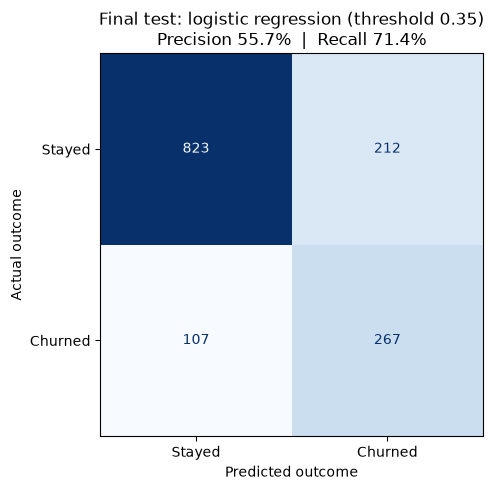

In [9]:
from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score
import matplotlib.pyplot as plt

final_pipe = clone(pipe)
final_pipe.fit(X_train, y_train)
test_churn_probabilities = final_pipe.predict_proba(X_test)[:, 1]
test_predictions_035 = np.where(test_churn_probabilities >= 0.35, "Yes", "No")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions_035,
    labels=["No", "Yes"],
    display_labels=["Stayed", "Churned"],
    cmap="Blues",
    colorbar=False,
    values_format="d",
    ax=ax,
)
precision = precision_score(y_test, test_predictions_035, pos_label="Yes")
recall = recall_score(y_test, test_predictions_035, pos_label="Yes")
ax.set_title(f"Final test: logistic regression (threshold 0.35)\nPrecision {precision:.1%}  |  Recall {recall:.1%}")
ax.set_xlabel("Predicted outcome")
ax.set_ylabel("Actual outcome")
fig.tight_layout()
fig.savefig("final_test_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()